In [13]:
import rioxarray as rxr

urban = rxr.open_rasterio("../.data/Zenodo/urban_fraction_1km.tif", masked=True)
print(urban)
print(urban.shape)
print(urban.rio.crs)
print(urban.x.min().item(), urban.x.max().item())
print(urban.y.min().item(), urban.y.max().item())

<xarray.DataArray (band: 1, y: 16000, x: 40000)> Size: 3GB
[640000000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 128kB 84.0 83.99 83.98 ... -59.98 -59.99 -60.0
  * x            (x) float64 320kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1
    STATISTICS_MEAN:           0.0019753378945111
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         0.025792830088559
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0
(1, 16000, 40000)
EPSG:4326
-179.9955 179.9955
-59.99549999999998 83.9955


In [14]:
urban = urban.squeeze("band", drop=True)
print(urban.shape)

(16000, 40000)


In [15]:
urban = urban.rename({"x": "lon", "y": "lat"})
print(urban)

<xarray.DataArray (lat: 16000, lon: 40000)> Size: 3GB
[640000000 values with dtype=float32]
Coordinates:
  * lat          (lat) float64 128kB 84.0 83.99 83.98 ... -59.98 -59.99 -60.0
  * lon          (lon) float64 320kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1
    STATISTICS_MEAN:           0.0019753378945111
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         0.025792830088559
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0


In [16]:
import xarray as xr

ds_target = xr.open_dataset("../.data/ETOPO2/topography_features_on_gridmet_masked_norm.nc")
target_lat = ds_target["lat"]
target_lon = ds_target["lon"]

print(target_lat.shape, target_lon.shape)

(240,) (311,)


In [17]:
if urban["lat"][0] > urban["lat"][-1]:
    urban = urban.sortby("lat")

In [18]:
urban_on_target = urban.interp(
    lon=target_lon,
    lat=target_lat,
    method="linear"
)

In [19]:
urban_on_target = urban_on_target.sortby("lat")

In [20]:
urban_on_target = urban_on_target.interpolate_na(dim="lon", method="nearest", fill_value="extrapolate")
urban_on_target = urban_on_target.interpolate_na(dim="lat", method="nearest", fill_value="extrapolate")

In [21]:
print(float(urban_on_target.min()), float(urban_on_target.max()))

0.0 0.9626736956839278


In [22]:
mask = ds_target["valid_mask"] if "valid_mask" in ds_target else None

if mask is not None:
    urban_on_target = urban_on_target.where(mask > 0.5)

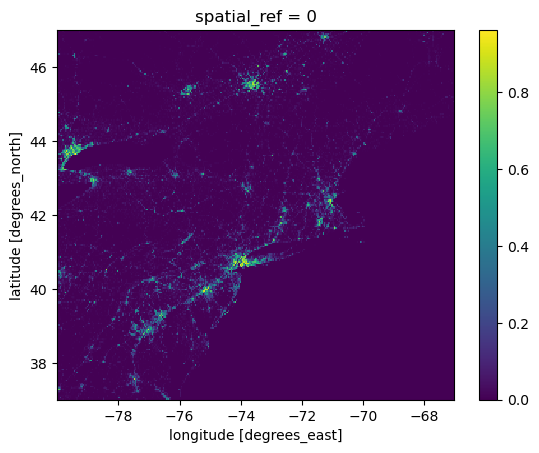

In [23]:
urban_on_target.plot()

In [24]:
urban_mean = urban_on_target.mean(skipna=True)
urban_std = urban_on_target.std(skipna=True)

urban_norm = (urban_on_target - urban_mean) / urban_std
urban_norm = urban_norm.fillna(0.0)

In [25]:
ds_out = xr.Dataset(
    {
        "urban_fraction": (("lat", "lon"), urban_on_target.astype("float32").values),
        "urban_fraction_norm": (("lat", "lon"), urban_norm.astype("float32").values),
    },
    coords={
        "lat": target_lat.values,
        "lon": target_lon.values,
    },
    attrs={
        "description": "Urban fraction regridded to target grid"
    }
)

out_path = "../.data/Zenodo/urban_fraction_on_gridmet_masked_norm.nc"
ds_out.to_netcdf(out_path)
print(f"Saved to {out_path}")

Saved to ../.data/Zenodo/urban_fraction_on_gridmet_masked_norm.nc
